Upload an image with at least one human face (jpg, png):


Saving images.jpg to images.jpg


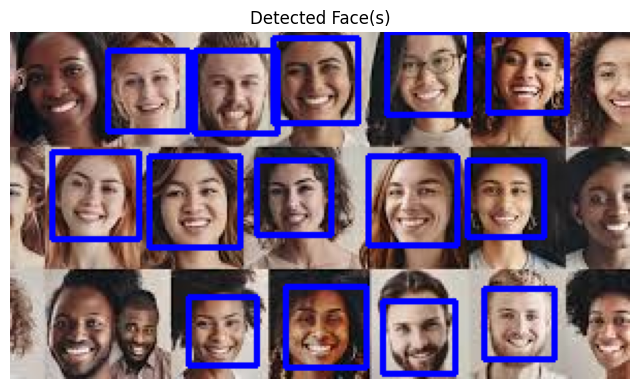

In [3]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files
# Step 1: Upload a face image
print("Upload an image with at least one human face (jpg, png):")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
# Step 2: Load Haar cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +'haarcascade_frontalface_default.xml')
# Step 3: Read and convert the image to grayscale
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Step 4: Detect faces
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
# Step 5: Draw rectangles around detected faces
for (x, y, w, h) in faces:
  cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
# Step 6: Display the result using matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Detected Face(s)")
plt.axis('off')
plt.show()

Upload a video file (e.g., .mp4, .avi):


Saving istockphoto-168586497-612x612.jpg to istockphoto-168586497-612x612.jpg


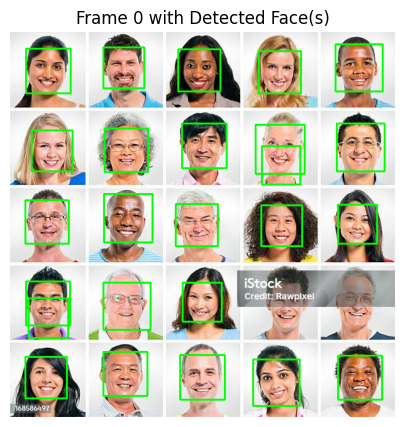

In [5]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import os
# Step 1: Upload a short video with a human face
print("Upload a video file (e.g., .mp4, .avi):")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
# Step 2: Load the Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +'haarcascade_frontalface_default.xml')
# Step 3: Read video file
cap = cv2.VideoCapture(video_path)
frame_count = 0
while True:
  ret, frame = cap.read()
  if not ret or frame_count >= 100: # limit to 100 frames to avoid long runtime
    break
  gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray, 1.1, 4)
  for (x, y, w, h) in faces:
    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
# Convert BGR to RGB for matplotlib
  rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
# Display every 20th frame
  if frame_count % 20 == 0:
    plt.figure(figsize=(8, 5))
    plt.imshow(rgb)
    plt.title(f"Frame {frame_count} with Detected Face(s)")
    plt.axis('off')
    plt.show()
  frame_count += 1
cap.release()

Upload a video file (e.g., .mp4, .avi):


Saving c9c1597f302e8f3344e16907392fa2a7.jpg to c9c1597f302e8f3344e16907392fa2a7.jpg


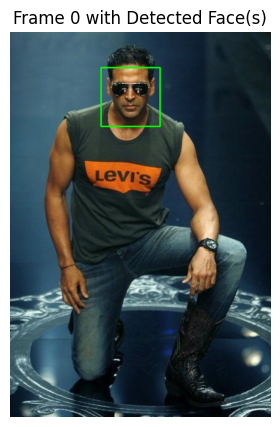

In [7]:
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Function to load dataset
def load_dataset(dataset_path):
    images = []
    labels = []
    label_dict = {}
    current_label = 0

    for person_name in os.listdir(dataset_path):
        person_path = os.path.join(dataset_path, person_name)
        if os.path.isdir(person_path):
            label_dict[current_label] = person_name
            for img_name in os.listdir(person_path):
                img_path = os.path.join(person_path, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                # Check if image loaded successfully and has valid dimensions
                if img is not None and img.shape[0] > 0 and img.shape[1] > 0:
                    images.append(img)
                    labels.append(current_label)
                else:
                    print(f"Failed to load or invalid image: {img_path}")
            current_label += 1

    return images, labels, label_dict

# Load dataset
dataset_path = '/content/face_recognition_dataset/Faces'
images, labels, label_dict = load_dataset(dataset_path)

# Create and train the LBPH face recognizer
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(images, np.array(labels))

# Save the trained model
recognizer.save('face_recognizer.yml')

# Save label map to file
with open("label_map.txt", "w") as f:
    for label, name in label_dict.items():
        f.write(f"{label}:{name}\n")

# Load the trained model
recognizer.read("face_recognizer.yml")

# Load Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Load label map from file
label_map = {}
with open("label_map.txt", "r") as f:
    for line in f:
        label, name = line.strip().split(":")
        label_map[int(label)] = name

# Load an image for recognition
img_path = "/content/face_recognition_dataset/Original Images/Original Images/Akshay Kumar/Akshay Kumar_0.jpg"
img = cv2.imread(img_path)

# Convert to grayscale for face detection
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

# Recognize faces
for (x, y, w, h) in faces:
    roi_gray = gray[y:y+h, x:x+w]
    label, confidence = recognizer.predict(roi_gray)
    name = label_map.get(label, "Unknown")
    # Draw rectangle and label
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(img, f"{name} ({int(confidence)})", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

# Display the result
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()